# 03 — Post-Silver Processing & Feature Contract

Turns canonical Silver into an analysis-ready frame and publishes the **leakage-safe feature contract** that Notebook 04 must follow.

| | |
|---|---|
| **Objective** | Define which rows are model-eligible and which columns may be used as predictors. |
| **Input** | `data/silver/rental_listings.parquet` (canonical Silver, read-only) |
| **Output** | In-memory eligibility flags, analysis-only variables, and the F1–F5 feature contract |
| **Out of scope** | Train/validation/test splits, model fitting and selection (Notebook 04 only); no files are written |

**Contents**

- Setup
- 01. Setup
- 02. Load canonical Silver
- 03. Model eligibility funnel
- 04. Analysis-only price per m²
- 05. Optional spatial diagnostic
- 06. Leakage-safe feature contract
- 07. Summary
- Summary

## Where this notebook sits

```mermaid
flowchart LR
    BR[("Bronze snapshot<br/>Parquet")] --> NB01 & NB02
    NB02 --> SV[("Silver<br/>rental_listings.parquet")]
    SV --> NB03 --> NB04 --> CH[("Locked champion<br/>LightGBM F4 RAW")]
    SV --> NB05
    CH --> NB06 & NB07
    NB01["01 · Raw EDA"]
    NB02["02 · Bronze → Silver"]
    NB03["03 · Feature contract"]
    NB04["04 · Price model"]
    NB05["05 · Nearby search"]
    NB06["06 · Shadow validation"]
    NB07["07 · Performance"]
    classDef current fill:#2a78d6,color:#ffffff,stroke:#184f95
    class NB03 current
```

The highlighted step is this notebook.

## 1. Setup

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = next(
    p
    for p in [Path.cwd(), *Path.cwd().parents]
    if (p / "crawler").is_dir() and (p / "analytics").is_dir()
)
sys.path.insert(0, str(PROJECT_ROOT))

import duckdb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from dotenv import load_dotenv
from IPython.display import Markdown, display

load_dotenv(PROJECT_ROOT / ".env", override=False)

from analytics.duckdb.connection import resolve_runtime_path
from roombeacon_crawler.config.get_env import env
from notebooks.utils.location_analysis import haversine_distance_km
from notebooks.utils.modeling_benchmark import (
    FORBIDDEN_PREDICTORS,
    TARGET,
    audit_features,
    build_feature_sets,
    build_modeling_eligibility,
    eligibility_funnel,
)
from notebooks.utils.notebook_style import (
    CATEGORICAL,
    NEUTRAL,
    apply_style,
    funnel_chart,
    histogram,
    share_chart,
)

apply_style()
pd.set_option("display.max_columns", 30)
SEED = 42

## 2. Load canonical Silver

Silver is read through an in-memory DuckDB connection (`:memory:`), so no database file is opened.
The grain is one row per `rental_post_id`.

In [2]:
SILVER_PATH = resolve_runtime_path(env.processing.silver_dir) / "rental_listings.parquet"
assert SILVER_PATH.exists(), f"Canonical Silver not found: {SILVER_PATH}"

with duckdb.connect(":memory:") as con:
    silver_df = con.execute("SELECT * FROM read_parquet(?)", [str(SILVER_PATH)]).df()

assert len(silver_df) > 0
assert silver_df.rental_post_id.notna().all() and silver_df.rental_post_id.is_unique

display(
    pd.Series(
        {
            "path": str(SILVER_PATH.relative_to(PROJECT_ROOT)),
            "rows": f"{len(silver_df):,}",
            "columns": len(silver_df.columns),
        },
        name="value",
    ).to_frame()
)

,value
path,data/silver/rental_listings.parquet
rows,"132,494"
columns,80


## 3. Model eligibility funnel

Each stage keeps only rows that pass one more rule, under the `PERMISSIVE` policy. Rows that leave the
funnel stay in Silver; they are simply not used as model targets.

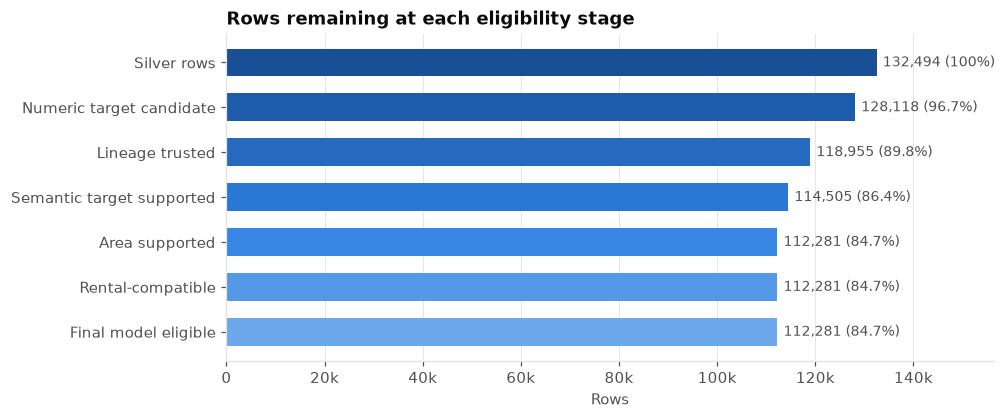

,Stage,Rows,Removed / reviewed,Percent of Silver,Policy
0,Silver rows,132494,0,100.000000,PERMISSIVE
1,Numeric target candidate,128118,4376,96.697209,PERMISSIVE
2,Lineage trusted,118955,9163,89.781424,PERMISSIVE
3,Semantic target supported,114505,4450,86.422781,PERMISSIVE
4,Area supported,112281,2224,84.744215,PERMISSIVE
5,Rental-compatible,112281,0,84.744215,PERMISSIVE
6,Final model eligible,112281,0,84.744215,PERMISSIVE


In [3]:
processed_df = silver_df.copy()
processing_masks = build_modeling_eligibility(processed_df, policy="PERMISSIVE")
processed_df["analytical_price_eligible"] = processing_masks.semantic_target_supported
processed_df["analytical_area_eligible"] = processing_masks.area_supported
processed_df["model_base_eligible"] = processing_masks.final_eligible

funnel = eligibility_funnel(processing_masks)
funnel_chart(funnel.set_index("Stage")["Rows"], title="Rows remaining at each eligibility stage")
plt.show()
display(funnel)

Which sources contribute model-eligible rows? Sources are sorted by total listings.

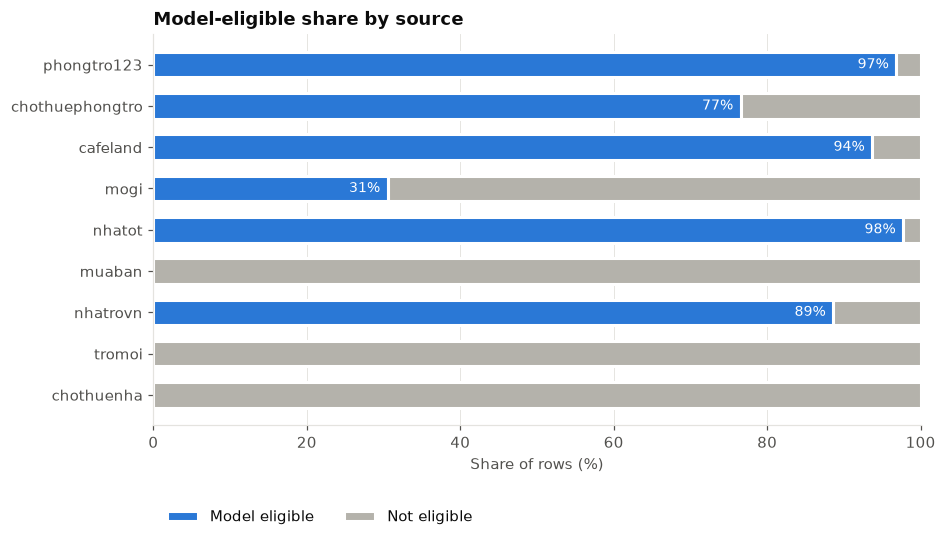

eligible,Model eligible,Not eligible,Total
source_code,,,
phongtro123,69138,2265,71403
chothuephongtro,27402,8394,35796
cafeland,9354,630,9984
mogi,2987,6795,9782
nhatot,2622,61,2683
muaban,0,1629,1629
nhatrovn,778,100,878
tromoi,0,255,255
chothuenha,0,84,84


In [4]:
by_source = (
    processed_df.assign(
        eligible=processed_df.model_base_eligible.map(
            {True: "Model eligible", False: "Not eligible"}
        )
    )
    .pivot_table(
        index="source_code",
        columns="eligible",
        values="rental_post_id",
        aggfunc="count",
        fill_value=0,
    )
    .reindex(columns=["Model eligible", "Not eligible"], fill_value=0)
)
by_source = by_source.loc[by_source.sum(axis=1).sort_values(ascending=False).index]
share_chart(
    by_source,
    title="Model-eligible share by source",
    colors={"Model eligible": CATEGORICAL[0], "Not eligible": NEUTRAL},
)
plt.show()
display(by_source.assign(Total=by_source.sum(axis=1)))

## 4. Analysis-only price per m²

`price_per_area_analysis` is **TARGET-DERIVED / ANALYSIS-ONLY**: it is computed from the target, so it is
useful for describing the market but is programmatically forbidden from every modeling feature set.

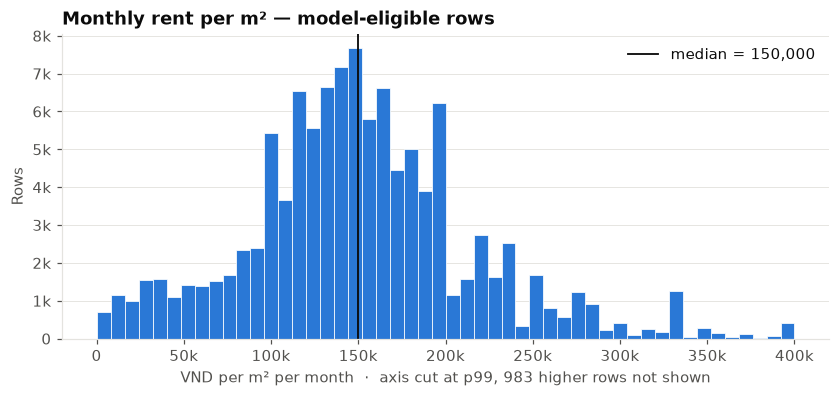

,price_per_area_analysis
count,1.122810e+05
mean,1.590076e+05
std,1.318866e+05
min,2.285714e+02
25%,1.136364e+05
50%,1.500000e+05
75%,1.866667e+05
max,1.000000e+07


In [5]:
price = pd.to_numeric(processed_df[TARGET], errors="coerce")
area = pd.to_numeric(processed_df.area_value_clean, errors="coerce")
processed_df["price_per_area_analysis"] = price / area.where(area.gt(0))
processed_df.loc[~np.isfinite(processed_df.price_per_area_analysis), "price_per_area_analysis"] = (
    np.nan
)

eligible_ppa = processed_df.loc[processed_df.model_base_eligible, "price_per_area_analysis"]
histogram(
    eligible_ppa, title="Monthly rent per m² — model-eligible rows", xlabel="VND per m² per month"
)
plt.show()
display(eligible_ppa.describe().to_frame("price_per_area_analysis"))

## 5. Optional spatial diagnostic

Distances are computed **only** for rows with a trusted map coordinate; no coordinate is inferred from
ward or district centroids. Set `REFERENCE_LOCATION = {"latitude": ..., "longitude": ...}` to enable it.

In [6]:
REFERENCE_LOCATION = None

processed_df["distance_km_analysis"] = np.nan
if REFERENCE_LOCATION is not None:
    if not {"latitude", "longitude"} <= set(REFERENCE_LOCATION):
        raise ValueError("REFERENCE_LOCATION requires latitude and longitude")
    trusted = processed_df.has_trusted_coordinate.fillna(False)
    processed_df.loc[trusted, "distance_km_analysis"] = haversine_distance_km(
        processed_df.loc[trusted, "map_latitude"],
        processed_df.loc[trusted, "map_longitude"],
        REFERENCE_LOCATION["latitude"],
        REFERENCE_LOCATION["longitude"],
    )

trusted_rows = int(processed_df.has_trusted_coordinate.sum())
display(
    pd.Series(
        {
            "trusted_coordinate_rows": f"{trusted_rows:,}",
            "trusted_coordinate_share": f"{trusted_rows / len(processed_df):.1%}",
            "distance_rows": int(processed_df.distance_km_analysis.notna().sum()),
        },
        name="value",
    ).to_frame()
)

,value
trusted_coordinate_rows,"2,277"
trusted_coordinate_share,1.7%
distance_rows,0


## 6. Leakage-safe feature contract

The five feature sets (F1–F5) are the only predictor lists Notebook 04 may evaluate. Every set is audited,
and the guard is proven to reject known leakage columns.

In [7]:
contract_frame = processed_df.assign(
    title_length=processed_df.title_clean.astype("string").str.len().astype("Float64")
)
SAFE_FEATURE_SETS = build_feature_sets(contract_frame.columns)
for features in SAFE_FEATURE_SETS.values():
    audit_features(features)

for forbidden in [
    "price_per_area_analysis",
    TARGET,
    "price_amount",
    "rental_post_id",
    "duplicate_candidate_group",
]:
    try:
        audit_features(["area_value_clean", forbidden])
    except ValueError:
        continue
    raise AssertionError(f"Leakage guard failed for {forbidden}")

feature_contract = pd.DataFrame(
    [
        {"Feature set": name, "Predictors": len(features), "Safe predictors": ", ".join(features)}
        for name, features in SAFE_FEATURE_SETS.items()
    ]
)
display(feature_contract)

,Feature set,Predictors,Safe predictors
0,F1 — AREA ONLY,1,area_value_clean
1,F2 — AREA + SOURCE,2,"area_value_clean, source_code"
2,F3 — AREA + LOCATION,3,"area_value_clean, ward_current, district_text_..."
3,F4 — AREA + SOURCE + LOCATION,4,"area_value_clean, source_code, ward_current, d..."
4,F5 — FULL SAFE TABULAR,6,"area_value_clean, source_code, ward_current, d..."


In [8]:
excluded = sorted(
    FORBIDDEN_PREDICTORS
    | {"all price_* status/evidence fields", "parser/quality fields that encode target validation"}
)
contract_summary = pd.DataFrame(
    [
        ("Target", TARGET),
        ("Safe candidates", ", ".join(sorted(set(sum(SAFE_FEATURE_SETS.values(), []))))),
        (
            "Grouping key source",
            "duplicate_candidate_group, falling back to rental_post_id in Notebook 04",
        ),
        ("Chronological time", "latest_observed_at"),
        ("Analysis-only", "price_per_area_analysis, distance_km_analysis"),
        (
            "Eligibility/audit (not predictors)",
            "listing_intent, rental_scope, price_target_trust_status, price_model_suitability, "
            "area_model_suitability, admin_consistency_status",
        ),
        ("Excluded / leakage", ", ".join(excluded)),
        ("Split owner", "Notebook 04 only"),
    ],
    columns=["Contract item", "Fields"],
)
display(contract_summary)
assert "dataset_split" not in processed_df.columns

,Contract item,Fields
0,Target,price_model_value
1,Safe candidates,"area_value_clean, district_text_extracted, pro..."
2,Grouping key source,"duplicate_candidate_group, falling back to ren..."
3,Chronological time,latest_observed_at
4,Analysis-only,"price_per_area_analysis, distance_km_analysis"
5,Eligibility/audit (not predictors),"listing_intent, rental_scope, price_target_tru..."
6,Excluded / leakage,"all price_* status/evidence fields, duplicate_..."
7,Split owner,Notebook 04 only


## 7. Summary

In [9]:
assert len(processed_df) == len(silver_df)
eligible_rows = int(processed_df.model_base_eligible.sum())
top_source = by_source["Model eligible"].idxmax()

display(
    Markdown(
        f"""
**Key findings**

- Silver holds **{len(silver_df):,}** listings; **{eligible_rows:,}** ({eligible_rows / len(silver_df):.1%}) are model-eligible.
- **{top_source}** contributes the most eligible rows ({int(by_source.loc[top_source, "Model eligible"]):,}).
- Median rent per m² among eligible rows is **{eligible_ppa.median():,.0f} VND** (analysis-only, never a predictor).
- Only **{trusted_rows / len(processed_df):.1%}** of listings have a trusted coordinate, so distance features stay optional.
- {len(SAFE_FEATURE_SETS)} feature sets passed the leakage audit; no split column and no dataset file were created.

**Next step:** Notebook 04 applies the group-aware chronological split and evaluates F1–F5.
"""
    )
)


**Key findings**

- Silver holds **132,494** listings; **112,281** (84.7%) are model-eligible.
- **phongtro123** contributes the most eligible rows (69,138).
- Median rent per m² among eligible rows is **150,000 VND** (analysis-only, never a predictor).
- Only **1.7%** of listings have a trusted coordinate, so distance features stay optional.
- 5 feature sets passed the leakage audit; no split column and no dataset file were created.

**Next step:** Notebook 04 applies the group-aware chronological split and evaluates F1–F5.
